In [134]:
import numpy as np
import pandas as pd 
import os
path = "D:\\other\\Dana\\traffic crashes\\chicago"
os.chdir(path)


In [135]:
import numpy as np
import pandas as pd
import logging
#!pip install dowhy
import dowhy
#!pip install econml
from dowhy import CausalModel
import dowhy.datasets

import econml
import warnings
warnings.filterwarnings('ignore')


In [136]:
df =pd.read_csv("chicago_crashes.csv")


In [137]:
df_ready = df[['SEX', 'AGE', 'SAFETY_EQUIPMENT', 'INJURY_CLASSIFICATION', 'AIRBAG_DEPLOYED',
       'DRIVER_ACTION', 'DRIVER_VISION', 'BAC_RESULT VALUE','CELL_PHONE_USE', 'MAKE', 'MODEL', 'VEHICLE_YEAR', 'VEHICLE_DEFECT',
       'VEHICLE_TYPE', 'VEHICLE_USE', 'MANEUVER', 'EXCEED_SPEED_LIMIT_I',
       'FIRST_CONTACT_POINT']]

In [138]:
value_mapping = {
    'SAFETY BELT USED': 1,
    'SAFETY BELT NOT USED': 0,}

df_ready['SAFETY_EQUIPMENT'].replace(value_mapping, inplace=True)


In [139]:
value_mapping = {
    'NO INDICATION OF INJURY': 0,
    'NONINCAPACITATING INJURY': 2,
    'REPORTED, NOT EVIDENT':1,
    'INCAPACITATING INJURY':3,
    'FATAL':4,}

df_ready['INJURY_CLASSIFICATION'].replace(value_mapping, inplace=True)

In [140]:
for column_name in df_ready.columns:
    
    df_ready[column_name].fillna('Unknown', inplace=True)

In [141]:
df_ready = df_ready[['SEX', 'AGE', 'SAFETY_EQUIPMENT', 'INJURY_CLASSIFICATION',
       'AIRBAG_DEPLOYED', 'DRIVER_ACTION', 'DRIVER_VISION', 'BAC_RESULT VALUE',
       'CELL_PHONE_USE', 'MAKE', 'MODEL', 'VEHICLE_YEAR', 'VEHICLE_DEFECT', 'MANEUVER', 'EXCEED_SPEED_LIMIT_I',
       'FIRST_CONTACT_POINT']]

In [142]:
df_ready.to_csv("cleaned_chicago_crashes_2.csv", index=False)

In [143]:
gml_content = """
graph [
  node [
    id 'MAKE'
  ]
  node [
    id 'MODEL'
  ]
  node [
    id 'VEHICLE_YEAR'
  ]
  node [
    id 'VEHICLE_TYPE'
  ]
  node [
    id 'VEHICLE_DEFECT'
  ]
  node [
    id 'FIRST_CONTACT_POINT'
  ]
  node [
    id 'AIRBAG_DEPLOYED'
  ]
  node [
    id 'BAC_RESULT_VALUE'
  ]
  node [
    id 'CELL_PHONE_USE'
  ]
  node [
    id 'DRIVER_ACTION'
  ]
  node [
    id 'EXCEED_SPEED_LIMIT_I'
  ]
  node [
    id 'SAFETY_EQUIPMENT'
  ]
  node [
    id 'MANEUVER'
  ]     
  node [
    id 'AGE'
  ]
  node [
    id 'SEX'
  ]
  node [
    id 'INJURY_CLASSIFICATION'
  ]
  node [
    id 'DRIVER_VISION'
  ]
  
  edge [
    source 'MAKE'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'MODEL'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'VEHICLE_YEAR'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'VEHICLE_TYPE'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'VEHICLE_DEFECT'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'FIRST_CONTACT_POINT'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'VEHICLE_DEFECT'
    target 'AIRBAG_DEPLOYED'
  ]
  edge [
    source 'FIRST_CONTACT_POINT'
    target 'AIRBAG_DEPLOYED'
  ]
  edge [
    source 'AIRBAG_DEPLOYED'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'BAC_RESULT_VALUE'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'CELL_PHONE_USE'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'DRIVER_ACTION'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'EXCEED_SPEED_LIMIT_I'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'SAFETY_EQUIPMENT'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'MANEUVER'
    target 'INJURY_CLASSIFICATION'
  ]
  edge [
    source 'AGE'
    target 'SEX'
  ]
  edge [
    source 'AGE'
    target 'CELL_PHONE_USE'
  ]
  edge [
    source 'AGE'
    target 'DRIVER_ACTION'
  ]
  edge [
    source 'AGE'
    target 'EXCEED_SPEED_LIMIT_I'
  ]
  edge [
    source 'AGE'
    target 'SAFETY_EQUIPMENT'
  ]
  edge [
    source 'SEX'
    target 'CELL_PHONE_USE'
  ]
  edge [
    source 'SEX'
    target 'DRIVER_ACTION'
  ]
  edge [
    source 'SEX'
    target 'EXCEED_SPEED_LIMIT_I'
  ]
  edge [
    source 'SEX'
    target 'SAFETY_EQUIPMENT'
  ]
  edge [
    source 'DRIVER_VISION'
    target 'DRIVER_ACTION'
  ]
  edge [
    source 'DRIVER_VISION'
    target 'EXCEED_SPEED_LIMIT_I'
  ]
  edge [
    source 'DRIVER_VISION'
    target 'SAFETY_EQUIPMENT'
  ]
]


"""


with open("causal_graph.gml", "w") as file:
    file.write(gml_content)


In [144]:
import networkx as nx

G = nx.DiGraph()

nodes = ['MAKE', 'MODEL', 'VEHICLE_YEAR', 'VEHICLE_DEFECT',
         'FIRST_CONTACT_POINT', 'AIRBAG_DEPLOYED', 'BAC_RESULT_VALUE',
         'CELL_PHONE_USE', 'DRIVER_ACTION', 'EXCEED_SPEED_LIMIT_I',
         'SAFETY_EQUIPMENT', 'MANEUVER', 'AGE', 'SEX', 'INJURY_CLASSIFICATION',
         'DRIVER_VISION']

G.add_nodes_from(nodes)


edges = [('MAKE', 'INJURY_CLASSIFICATION'),
         ('MODEL', 'INJURY_CLASSIFICATION'),
         ('VEHICLE_YEAR', 'INJURY_CLASSIFICATION'),
         ('VEHICLE_DEFECT', 'INJURY_CLASSIFICATION'),
         ('FIRST_CONTACT_POINT', 'INJURY_CLASSIFICATION'),
         ('VEHICLE_DEFECT', 'AIRBAG_DEPLOYED'),
         ('FIRST_CONTACT_POINT', 'AIRBAG_DEPLOYED'),
         ('AIRBAG_DEPLOYED', 'INJURY_CLASSIFICATION'),
         ('BAC_RESULT_VALUE', 'INJURY_CLASSIFICATION'),
         ('CELL_PHONE_USE', 'INJURY_CLASSIFICATION'),
         ('DRIVER_ACTION', 'INJURY_CLASSIFICATION'),
         ('EXCEED_SPEED_LIMIT_I', 'INJURY_CLASSIFICATION'),
         ('SAFETY_EQUIPMENT', 'INJURY_CLASSIFICATION'),
         ('MANEUVER', 'INJURY_CLASSIFICATION'),
         ('AGE', 'SEX'),
         ('AGE', 'CELL_PHONE_USE'),
         ('AGE', 'DRIVER_ACTION'),
         ('AGE', 'EXCEED_SPEED_LIMIT_I'),
         ('AGE', 'SAFETY_EQUIPMENT'),
         ('SEX', 'CELL_PHONE_USE'),
         ('SEX', 'DRIVER_ACTION'),
         ('SEX', 'EXCEED_SPEED_LIMIT_I'),
         ('SEX', 'SAFETY_EQUIPMENT'),
         ('DRIVER_VISION', 'DRIVER_ACTION'),
         ('DRIVER_VISION', 'EXCEED_SPEED_LIMIT_I'),
         ('DRIVER_VISION', 'SAFETY_EQUIPMENT')]

G.add_edges_from(edges)

nx.write_gml(G, 'causal_graphnx.gml')


In [145]:
graph_file = "causal_graphnx.gml"

treatment_variable = 'SAFETY_EQUIPMENT'
outcome_variable = 'INJURY_CLASSIFICATION'

model = CausalModel(data=df_ready,
                    treatment=treatment_variable, outcome=outcome_variable,
                    graph=graph_file)


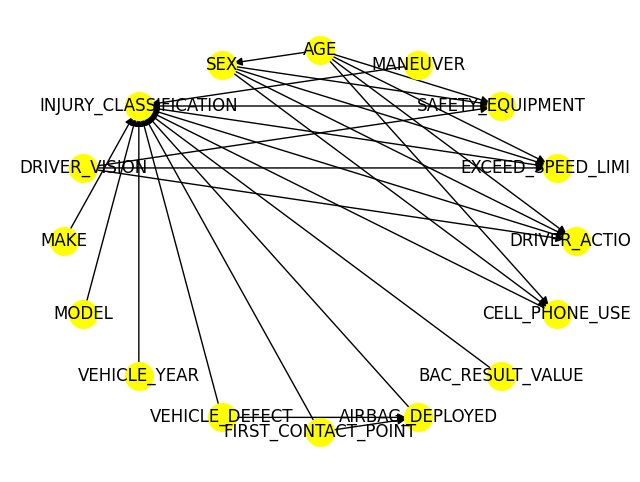

In [146]:
model.view_model()


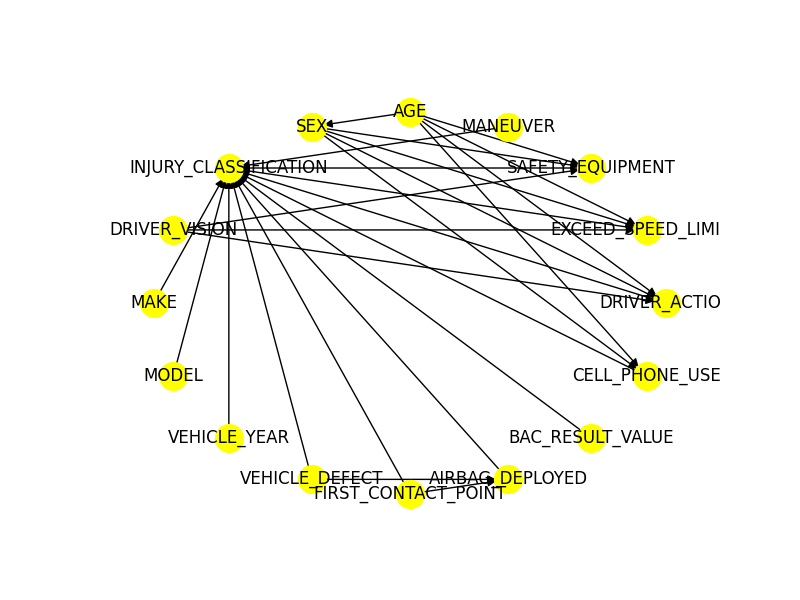

In [147]:
from IPython.display import Image, display
display(Image(filename="causal_model.png"))

In [148]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: nonparametric-ate

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                         
───────────────────(E[INJURY_CLASSIFICATION|SEX,DRIVER_VISION,AGE])
d[SAFETY_EQUIPMENT]                                                
Estimand assumption 1, Unconfoundedness: If U→{SAFETY_EQUIPMENT} and U→INJURY_CLASSIFICATION then P(INJURY_CLASSIFICATION|SAFETY_EQUIPMENT,SEX,DRIVER_VISION,AGE,U) = P(INJURY_CLASSIFICATION|SAFETY_EQUIPMENT,SEX,DRIVER_VISION,AGE)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



In [149]:
causal_estimate = model.estimate_effect(identified_estimand, method_name="backdoor.propensity_score_stratification")
print(causal_estimate)

propensity_score_stratification
*** Causal Estimate ***

## Identified estimand
Estimand type: nonparametric-ate

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                         
───────────────────(E[INJURY_CLASSIFICATION|SEX,DRIVER_VISION,AGE])
d[SAFETY_EQUIPMENT]                                                
Estimand assumption 1, Unconfoundedness: If U→{SAFETY_EQUIPMENT} and U→INJURY_CLASSIFICATION then P(INJURY_CLASSIFICATION|SAFETY_EQUIPMENT,SEX,DRIVER_VISION,AGE,U) = P(INJURY_CLASSIFICATION|SAFETY_EQUIPMENT,SEX,DRIVER_VISION,AGE)

## Realized estimand
b: INJURY_CLASSIFICATION~SAFETY_EQUIPMENT+SEX+DRIVER_VISION+AGE
Target units: ate

## Estimate
Mean value: -0.2007067601478385

